# Model Training

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [7]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [8]:
df.columns # no need od day , month , year to calculate FWI

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [9]:
# drop month , date , year
df.drop(['day','month','year'],axis=1,inplace=True)

In [10]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [11]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [12]:
#Encoding 
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [13]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [14]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1.0
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1.0
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1.0
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1.0
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,NaN


In [15]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [16]:
## Dividing the features into independent and dependent feature 
X=df.drop('FWI',axis=1)
y=df['FWI']

In [17]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0.0


In [18]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [19]:
## Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [20]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [21]:
# Feature selection based of corr
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.282455
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.404088
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.180818
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.038932
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.226019
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.196463
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.076095
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.267704
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.093212
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.201497


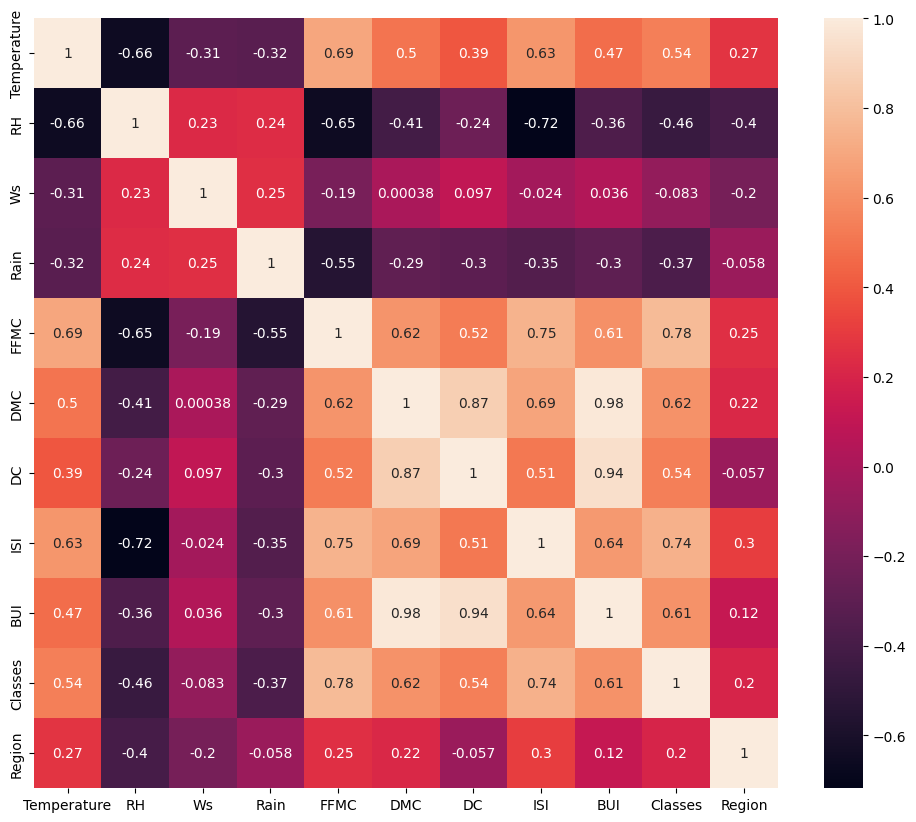

In [22]:
# check multicollinearity -> like our independent feature should not that much correlated based on threshold value
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [23]:
## assume threshold value is 0.95 so they grab the value nearest to the thresold , so we can remove it 
def correlation(dataset, threshold):
  col_corr = set()
  corr_matrix=dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j]) > threshold:
        colname = corr_matrix.columns[i]
        col_corr.add(colname)
  return col_corr

In [24]:
## thresold set by domain expertise
corr_features = correlation(X_train,0.85)

In [25]:
# Drop features when correlation is more than 0.85

X_test.drop(corr_features,axis=1,inplace=True)
X_train.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

# Feature Scaling or standardization

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [27]:
X_train_scaled # all the value in standar values 

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98356052],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01671425],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01671425],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98356052],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01671425],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98356052]], shape=(182, 9))

# Box plot to understand effect of standard scaler

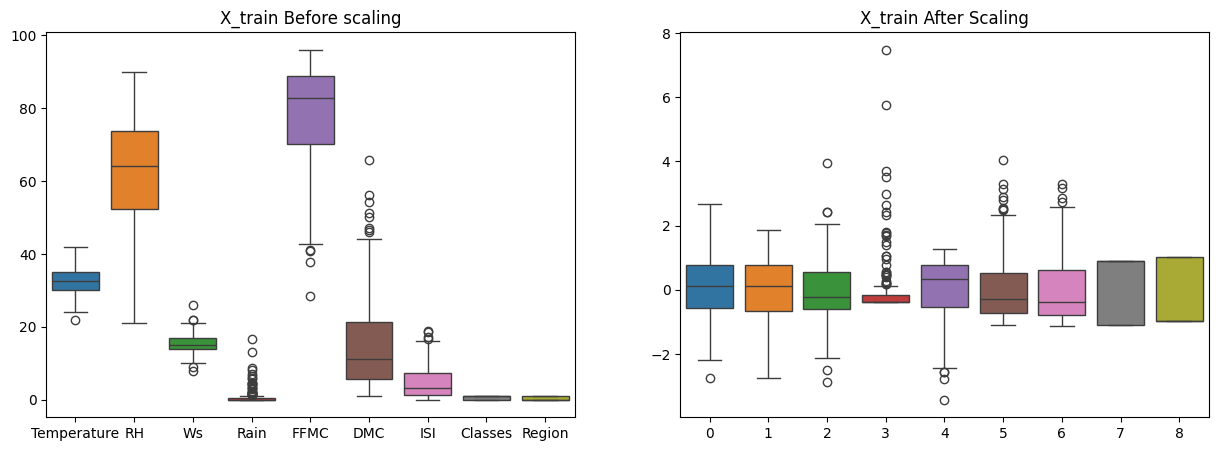

In [28]:
# standardisation
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')
plt.show()

In [29]:
X_train.isnull().sum()

Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
ISI            0
Classes        0
Region         1
dtype: int64

In [30]:
df=df.dropna().reset_index(drop=True)

In [31]:
X_train.isna().sum()

Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
ISI            0
Classes        0
Region         1
dtype: int64

In [32]:
np.isnan(X_train_scaled).sum()


np.int64(1)

In [33]:
X_train=X_train.dropna().reset_index(drop=True)

In [34]:
X_train.isna().any().any()

np.False_

In [35]:
np.where(np.isnan(X_train_scaled).any(axis=1))

(array([173]),)

In [36]:
df.iloc[173]

Temperature    31.0
RH             71.0
Ws             17.0
Rain            0.0
FFMC           87.3
DMC            46.6
DC             99.0
ISI             6.9
BUI            46.5
FWI            16.3
Classes         1.0
Region          1.0
Name: 173, dtype: float64

In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled  = imputer.transform(X_test_scaled)


# Linear Regression

Mean absoulte error: 0.546637433707761
R^2 score: 0.9848164377199702


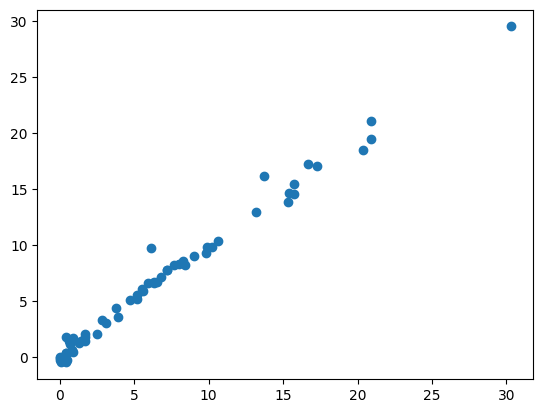

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
# y_pred=linreg.predict(X_test) # give negative value 
y_pred=linreg.predict(X_test_scaled) # correct
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absoulte error:",mae)
print("R^2 score:",score) # explain how much of the variation in the dependent variable can be explained by an independent varibale
plt.scatter(y_test,y_pred)

Mean absoulte error: 1.133175994914409
R^2 score: 0.9492020263112388


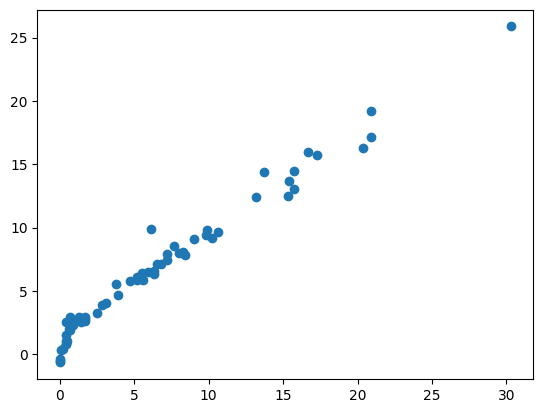

In [39]:
# Lasso regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error , r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
# y_pred=linreg.predict(X_test) # give negative value 
y_pred=lasso.predict(X_test_scaled) # correct
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absoulte error:",mae)
print("R^2 score:",score) # explain how much of the variation in the dependent variable can be explained by an independent varibale
plt.scatter(y_test,y_pred)
# Overfitting the condition

# Cross validation Lasso

In [40]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

In [ ]:
lassocv.predict(X_test_scaled)  # prediction is done there

array([ 8.17921034,  7.68736198, -0.26644415,  4.71768388,  6.78185776,
        1.76684796,  2.22513234,  7.63547836,  1.99165732,  3.3996395 ,
        0.62764292,  9.95184628,  9.35710591, 16.98232777, 18.29172443,
        1.60703588,  1.61822577, -0.64181583,  7.28917657,  3.10306748,
        1.95532691,  0.18035666,  6.47959583,  0.14285638, 20.99462292,
        5.11186575,  5.86577266,  9.7638059 , -0.7705644 ,  9.91403698,
        6.72669646, -0.32750538, 10.31595188, 14.4423099 ,  1.71006666,
        0.82481064,  2.03695021,  5.96934265, -0.63597101, -0.57155566,
        6.47635864,  2.07960322,  8.47174076, -0.84675489, 15.40147158,
        8.33373514,  8.48292394,  1.44015771, 13.0238593 ,  1.20892958,
       29.08644324,  5.49176716, 17.15703526, 19.29587938, 13.7168802 ,
       16.05949683,  0.98102786,  9.08273568,  3.83857645, 14.43659554,
        5.22473116])

In [44]:
lassocv.alpha_

np.float64(0.05725391318234408)

In [45]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [ ]:
lassocv.mse_path_ # mse of every point

array([[53.64536329, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139716, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

Mean absolute error : 0.6194648383315131
R2 Score 0.9821393335524257


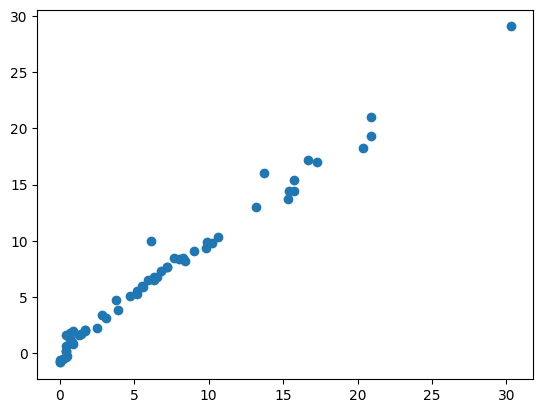

In [48]:
y_pred=lassocv.predict(X_test_scaled) # prediction
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error :",mae)
print("R2 Score",score)

Mean absoulte error: 0.5636496918362448
R^2 score: 0.9843521331346774


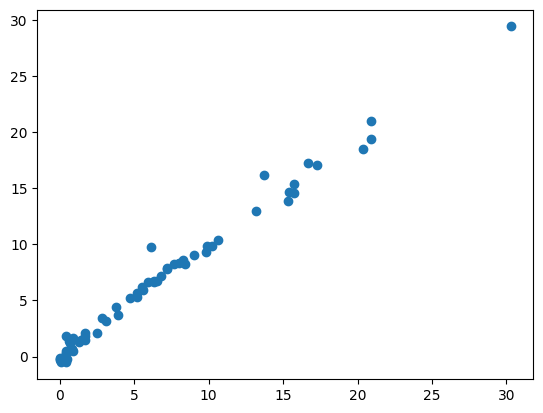

In [41]:
# RIdge Regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error , r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled) # correct
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absoulte error:",mae)
print("R^2 score:",score) # explain how much of the variation in the dependent variable can be explained by an independent varibale
plt.scatter(y_test,y_pred)

Mean absolute error : 0.5636496918362448
R2 Score 0.9843521331346774


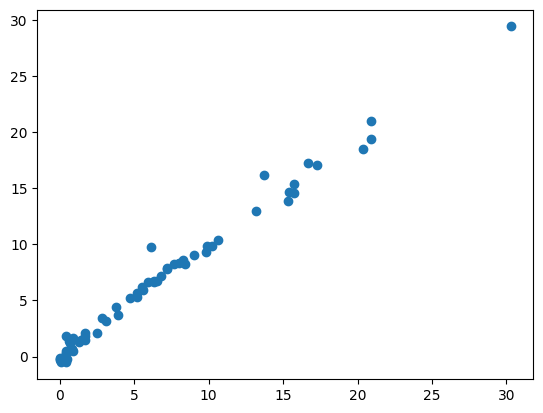

In [54]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error :",mae)
print("R2 Score",score)

In [56]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [57]:
ridgecv.get_params

<bound method BaseEstimator.get_params of RidgeCV(cv=5)>

# Elastic net regression

Mean absoulte error: 1.8822353634896005
R^2 score: 0.8753460589519703


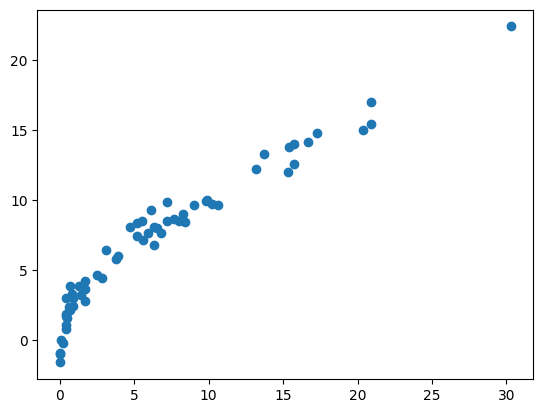

In [42]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error , r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled) # correct
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absoulte error:",mae)
print("R^2 score:",score) # explain how much of the variation in the dependent variable can be explained by an independent varibale
plt.scatter(y_test,y_pred)

Mean absolute error : 0.5636496918362448
R2 Score 0.9843521331346774


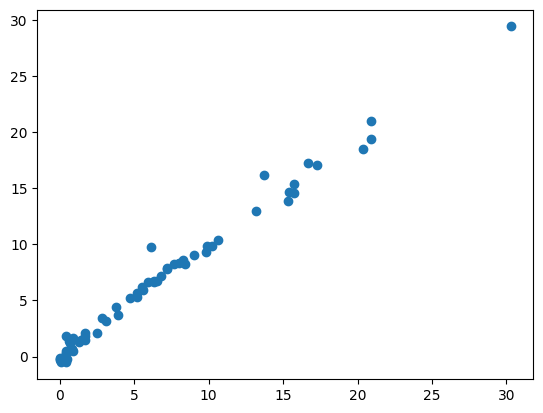

In [58]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error :",mae)
print("R2 Score",score)

In [59]:
elasticcv.alpha_

np.float64(0.04020589334346346)